# 🎵 Entrenamiento de Modelos — Mood Classifier
Notebook interactivo con progreso en tiempo real, métricas por fold y visualizaciones de validación.

## 0. Imports y configuración

In [35]:
from __future__ import annotations

import json
import logging
import shutil
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import boto3
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, clear_output, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm

matplotlib.use('Agg')
%matplotlib inline

warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
LOGGER = logging.getLogger('train_models')

print('✅ Imports OK')

✅ Imports OK


## 1. Parámetros globales

In [36]:
# ── Ajusta estos valores antes de ejecutar ──────────────────────────────────
import sys
from pathlib import Path

ROOT = Path(".").resolve().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RANDOM_STATE     = 42
TARGET_COL       = 'mood_label'
CV_SPLITS        = 3          # folds para GridSearchCV
SOURCE           = 'auto'     # 'auto' | 's3' | 'local'
SPLIT_STRATEGY   = 'deduplicated'   # 'deduplicated' | 'prepared'
SKIP_PLOTS       = False
UPLOAD_TO_S3     = True
OUTPUT_DIR       = ROOT / 'models'
# ────────────────────────────────────────────────────────────────────────────

LABEL_NAMES = {0: 'sad', 1: 'happy', 2: 'energetic', 3: 'calm'}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR = ROOT / 'data_lake' / 'model_outputs' / 'mood_classifier'
PLOTS_DIR       = OUTPUT_DATA_DIR / 'plots'
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT          : {ROOT}')
print(f'OUTPUT_DIR    : {OUTPUT_DIR}')
print(f'OUTPUT_DATA   : {OUTPUT_DATA_DIR}')
print(f'CV_SPLITS     : {CV_SPLITS}')
print(f'SPLIT_STRATEGY: {SPLIT_STRATEGY}')

ROOT          : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender
OUTPUT_DIR    : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models
OUTPUT_DATA   : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\model_outputs\mood_classifier
CV_SPLITS     : 3
SPLIT_STRATEGY: deduplicated


## 2. Funciones auxiliares

In [37]:
def select_feature_columns(df: pd.DataFrame) -> list[str]:
    ignored = {TARGET_COL, 'mood_name', 'uri', 'track_id'}
    return [c for c in df.columns if c not in ignored and pd.api.types.is_numeric_dtype(df[c])]


def build_split_report(train_df, test_df, feature_cols):
    train_dup = int(train_df.duplicated(feature_cols).sum())
    test_dup  = int(test_df.duplicated(feature_cols).sum())
    overlap = test_df.reset_index().merge(
        train_df[[*feature_cols, TARGET_COL]], on=feature_cols,
        how='inner', suffixes=('_test', '_train'))
    overlap_rows = int(overlap['index'].nunique()) if not overlap.empty else 0
    label_agreement = (
        float((overlap[f'{TARGET_COL}_test'] == overlap[f'{TARGET_COL}_train']).mean())
        if not overlap.empty else None)
    return {
        'train_rows': int(len(train_df)),
        'test_rows':  int(len(test_df)),
        'train_duplicate_feature_rows': train_dup,
        'test_duplicate_feature_rows':  test_dup,
        'test_rows_with_feature_overlap': overlap_rows,
        'feature_overlap_label_agreement': label_agreement,
    }


def prepare_modeling_split(train_df, test_df, split_strategy):
    feature_cols = select_feature_columns(train_df)
    report = build_split_report(train_df, test_df, feature_cols)
    if split_strategy == 'prepared':
        return train_df, test_df, report
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    before  = len(full_df)
    conflicts = int(full_df.groupby(feature_cols)[TARGET_COL].nunique().gt(1).sum())
    if conflicts:
        print(f'⚠️  {conflicts} combinaciones con más de una etiqueta — se conserva la primera.')
    dedup = full_df.drop_duplicates(subset=[*feature_cols, TARGET_COL]).reset_index(drop=True)
    train_new, test_new = train_test_split(
        dedup, test_size=0.2, stratify=dedup[TARGET_COL], random_state=RANDOM_STATE)
    train_new = train_new.reset_index(drop=True)
    test_new  = test_new.reset_index(drop=True)
    new_report = build_split_report(train_new, test_new, feature_cols)
    new_report.update({
        'strategy_note': 'Split rehecho tras eliminar duplicados exactos.',
        'original_rows': before,
        'deduplicated_rows': len(dedup),
        'removed_duplicate_rows': before - len(dedup),
        'feature_target_conflicts': conflicts,
        'original_prepared_split_report': report,
    })
    return train_new, test_new, new_report


def split_features_target(train_df, test_df):
    if TARGET_COL not in train_df.columns or TARGET_COL not in test_df.columns:
        raise ValueError(f'El target {TARGET_COL!r} debe existir en train y test.')
    feature_cols = select_feature_columns(train_df)
    if not feature_cols:
        raise ValueError('No se encontraron features numéricas para entrenar.')
    return (
        train_df[feature_cols], train_df[TARGET_COL].astype(int),
        test_df[feature_cols],  test_df[TARGET_COL].astype(int),
        feature_cols,
    )


def predict_proba_if_available(model, X):
    return model.predict_proba(X) if hasattr(model, 'predict_proba') else None


def calculate_roc_auc(y_true, y_proba):
    if y_proba is None:
        return None
    try:
        return float(roc_auc_score(
            y_true, y_proba, labels=sorted(LABEL_NAMES),
            multi_class='ovr', average='macro'))
    except ValueError:
        return None


def build_predictions_frame(model_name, y_true, y_pred, y_proba):
    frame = pd.DataFrame({
        'model': model_name,
        'sample_index': range(len(y_true)),
        'real_label':      y_true.to_numpy(),
        'real_mood':       [LABEL_NAMES[int(l)] for l in y_true.to_numpy()],
        'predicted_label': y_pred,
        'predicted_mood':  [LABEL_NAMES[int(l)] for l in y_pred],
        'is_correct':      y_true.to_numpy() == y_pred,
    })
    if y_proba is not None:
        for idx, label in enumerate(sorted(LABEL_NAMES)):
            frame[f'proba_{LABEL_NAMES[label]}'] = y_proba[:, idx]
        frame['prediction_confidence'] = y_proba.max(axis=1)
    return frame


def build_model_specs():
    return {
        'logistic_regression': {
            'pipeline': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', LogisticRegression(
                    solver='lbfgs', max_iter=5000,
                    class_weight='balanced', random_state=RANDOM_STATE)),
            ]),
            'param_grid': {
                'model__C': [0.1, 1.0, 10.0],
                'model__fit_intercept': [True, False],
            },
        },
        'random_forest': {
            'pipeline': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', RandomForestClassifier(
                    random_state=RANDOM_STATE, n_jobs=-1)),
            ]),
            'param_grid': {
                'model__n_estimators':    [200, 400],
                'model__max_depth':       [None, 10, 20],
                'model__min_samples_leaf':[1, 3],
                'model__class_weight':    ['balanced', 'balanced_subsample'],
            },
        },
    }

print('✅ Funciones auxiliares cargadas')

✅ Funciones auxiliares cargadas


## 3. Carga de datos Gold

In [38]:
def download_s3_prefix(settings, prefix, target_dir):
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    client = boto3.client('s3', region_name=settings.aws_region,
                          endpoint_url=settings.s3_endpoint_url)
    paginator = client.get_paginator('list_objects_v2')
    found = False
    for page in paginator.paginate(Bucket=settings.bucket_name, Prefix=prefix):
        for item in page.get('Contents', []):
            key = item['Key']
            if key.endswith('/'): continue
            found = True
            relative = Path(key).relative_to(prefix.rstrip('/'))
            dest = target_dir / relative
            dest.parent.mkdir(parents=True, exist_ok=True)
            client.download_file(settings.bucket_name, key, str(dest))
    if not found:
        raise FileNotFoundError(f'No hay objetos en s3://{settings.bucket_name}/{prefix}')


def resolve_gold_paths(source, settings=None):
    if source in {'s3', 'auto'} and settings is not None:
        try:
            cache_dir = ROOT / 'data_lake' / 's3_cache' / 'gold' / 'mood_prepared'
            print('⬇️  Descargando datos Gold desde S3…')
            download_s3_prefix(settings, 'gold/mood_prepared/train/', cache_dir / 'train')
            download_s3_prefix(settings, 'gold/mood_prepared/test/',  cache_dir / 'test')
            print('✅ Descarga S3 completada')
            return (cache_dir / 'train', cache_dir / 'test',
                    f"s3://{settings.bucket_name}/gold/mood_prepared")
        except Exception as exc:
            if source == 's3':
                raise
            print(f'⚠️  S3 no disponible ({exc}). Usando copia local.')

    local_base = ROOT / 'data_lake' / 'tmp_gold' / 'mood_prepared'
    if not (local_base / 'train').exists() or not (local_base / 'test').exists():
        raise FileNotFoundError(
            'No se encontró Gold local en data_lake/tmp_gold/mood_prepared.\n'
            'Ejecuta primero preparacion_datos.ipynb o usa SOURCE="s3".')
    return local_base / 'train', local_base / 'test', str(local_base)


# --- Intenta cargar settings (si no existe, sigue sin S3) ---
try:
    from src.config import load_settings
    settings = load_settings()
    print('✅ Settings cargados')
except Exception as e:
    settings = None
    print(f'ℹ️  src.config no disponible ({e}). Se usará ruta local.')

train_path, test_path, source_used = resolve_gold_paths(SOURCE, settings)

print(f'\n📂 Fuente: {source_used}')
print(f'   Train : {train_path}')
print(f'   Test  : {test_path}')

✅ Settings cargados
⬇️  Descargando datos Gold desde S3…
✅ Descarga S3 completada

📂 Fuente: s3://music-recommender-data-lake-246681677043/gold/mood_prepared
   Train : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\s3_cache\gold\mood_prepared\train
   Test  : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\s3_cache\gold\mood_prepared\test


In [39]:
print('Leyendo parquet…')
train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)

print(f'\n📊 Train shape: {train_df.shape}  |  Test shape: {test_df.shape}')
print(f'\nDistribución de clases — TRAIN')
display(train_df[TARGET_COL].map(LABEL_NAMES).value_counts().rename('count').to_frame())
print(f'\nDistribución de clases — TEST')
display(test_df[TARGET_COL].map(LABEL_NAMES).value_counts().rename('count').to_frame())
print('\nPrimeras filas de train:')
display(train_df.head())

Leyendo parquet…

📊 Train shape: (128764, 11)  |  Test shape: (31236, 11)

Distribución de clases — TRAIN


,count
mood_label,
happy,48273
sad,38261
energetic,22607
calm,19623



Distribución de clases — TEST


,count
mood_label,
happy,11797
sad,9267
energetic,5429
calm,4743



Primeras filas de train:


,mood_label,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms
0,1,-2.521687,1.179779,-0.365616,-0.653604,1.824340,2.297830,-1.682804,-2.311406,-1.335240,-0.890013
1,1,-2.463330,1.547992,0.210634,-0.111842,1.066020,2.297830,-1.660130,-0.475681,-1.282651,-1.144612
2,1,-2.120022,0.556650,-0.437929,-0.653604,1.882672,2.297830,-1.699250,-0.692359,-1.676694,-1.321861
3,1,-2.104250,0.691190,-0.175792,0.176734,1.569799,1.418245,0.243657,0.444510,-1.277487,-1.537748
4,1,-2.104250,1.530289,-0.137376,-0.653604,1.821689,1.598717,-1.666358,-0.841757,-0.587420,-1.023374


## 4. Preparación del split

In [40]:
print(f'Estrategia de split: {SPLIT_STRATEGY}')
train_df, test_df, split_report = prepare_modeling_split(train_df, test_df, SPLIT_STRATEGY)
X_train, y_train, X_test, y_test, feature_cols = split_features_target(train_df, test_df)

print(f'\n✅ Split listo')
print(f'   X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'   Features ({len(feature_cols)}): {feature_cols}')
print(f'\n--- Informe de split ---')
for k, v in split_report.items():
    if k != 'original_prepared_split_report':
        print(f'  {k}: {v}')

# Comprobación rápida de NaN
nan_train = X_train.isna().sum().sum()
nan_test  = X_test.isna().sum().sum()
print(f'\n🔍 NaN en X_train: {nan_train}  |  NaN en X_test: {nan_test}')

Estrategia de split: deduplicated

✅ Split listo
   X_train: (127475, 10)  |  X_test: (31869, 10)
   Features (10): ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo', 'duration_ms']

--- Informe de split ---
  train_rows: 127475
  test_rows: 31869
  train_duplicate_feature_rows: 0
  test_duplicate_feature_rows: 0
  test_rows_with_feature_overlap: 0
  feature_overlap_label_agreement: None
  strategy_note: Split rehecho tras eliminar duplicados exactos.
  original_rows: 160000
  deduplicated_rows: 159344
  removed_duplicate_rows: 656
  feature_target_conflicts: 0

🔍 NaN en X_train: 0  |  NaN en X_test: 0


## 5. Entrenamiento con GridSearchCV

> Cada modelo muestra su progreso por fold y el mejor set de hiperparámetros encontrado.

In [41]:
from sklearn.model_selection import ParameterGrid
import time

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
model_specs = build_model_specs()

results: list[dict] = []
cv_rows: list[pd.DataFrame] = []
prediction_rows: list[pd.DataFrame] = []
fitted_models: dict[str, GridSearchCV] = {}

TOTAL_MODELS = len(model_specs)
print(f'Modelos a entrenar: {TOTAL_MODELS}')
print(f'CV folds:           {CV_SPLITS}')
print(f'Scoring:            f1_macro\n')

for model_idx, (name, spec) in enumerate(model_specs.items(), start=1):

    param_list = list(ParameterGrid(spec['param_grid']))
    n_combinations = len(param_list)
    total_fits = n_combinations * CV_SPLITS

    print('─' * 60)
    print(f'[{model_idx}/{TOTAL_MODELS}] 🚀 {name}')
    print(f'    Combinaciones: {n_combinations}  |  Fits totales: {total_fits}')
    print(f'    Grid:')
    for param, values in spec['param_grid'].items():
        print(f'      {param}: {values}')

    t0 = time.time()

    search = GridSearchCV(
        estimator=spec['pipeline'],
        param_grid=spec['param_grid'],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        verbose=10,  # 🔥 más detalle
    )

    print('\n⏳ Entrenando... (esto puede tardar)')
    search.fit(X_train, y_train)

    elapsed = time.time() - t0

    # 🔥 cálculo de tiempos
    avg_time_per_fit = elapsed / total_fits
    estimated_total = avg_time_per_fit * total_fits
    remaining = estimated_total - elapsed

    # ── Métricas en test ────────────────────────────────────────────────────
    y_pred  = search.predict(X_test)
    y_proba = predict_proba_if_available(search.best_estimator_, X_test)
    report  = classification_report(
        y_test, y_pred,
        labels=sorted(LABEL_NAMES),
        target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)],
        output_dict=True, zero_division=0)
    roc_auc_ovr = calculate_roc_auc(y_test, y_proba)

    result = {
        'model':                   name,
        'best_params':             search.best_params_,
        'best_cv_f1_macro':        float(search.best_score_),
        'test_f1_macro':           float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
        'test_f1_weighted':        float(f1_score(y_test, y_pred, average='weighted', zero_division=0)),
        'test_precision_macro':    float(precision_score(y_test, y_pred, average='macro', zero_division=0)),
        'test_recall_macro':       float(recall_score(y_test, y_pred, average='macro', zero_division=0)),
        'test_precision_weighted': float(precision_score(y_test, y_pred, average='weighted', zero_division=0)),
        'test_recall_weighted':    float(recall_score(y_test, y_pred, average='weighted', zero_division=0)),
        'test_accuracy':           float(accuracy_score(y_test, y_pred)),
        'test_roc_auc_ovr_macro':  roc_auc_ovr,
        'classification_report':   report,
        'elapsed_seconds':         round(elapsed, 1),
    }

    results.append(result)
    fitted_models[name] = search
    prediction_rows.append(build_predictions_frame(name, y_test, y_pred, y_proba))

    cv_result = pd.DataFrame(search.cv_results_)
    cv_result.insert(0, 'model', name)
    cv_rows.append(cv_result)

    # ── Resumen con tiempo ──────────────────────────────────────────────────
    print(f'\n    ✅ Entrenado en {elapsed:.1f}s')
    print(f'    ⏱️ Tiempo medio por fit: {avg_time_per_fit:.2f}s')
    print(f'    📊 Estimación total:     {estimated_total:.1f}s')
    print(f'    ⏳ Tiempo restante:      {remaining:.1f}s')
    print(f'    Mejores parámetros:     {search.best_params_}')
    print(f'    CV f1_macro (best):     {result["best_cv_f1_macro"]:.4f}')
    print(f'    Test f1_macro:          {result["test_f1_macro"]:.4f}')
    print(f'    Test accuracy:          {result["test_accuracy"]:.4f}')
    print(f'    Test ROC-AUC (ovr):     {result["test_roc_auc_ovr_macro"]}')
    print()

print('=' * 60)
print('🏁 Entrenamiento completado')

Modelos a entrenar: 2
CV folds:           3
Scoring:            f1_macro

────────────────────────────────────────────────────────────
[1/2] 🚀 logistic_regression
    Combinaciones: 6  |  Fits totales: 18
    Grid:
      model__C: [0.1, 1.0, 10.0]
      model__fit_intercept: [True, False]

⏳ Entrenando... (esto puede tardar)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

    ✅ Entrenado en 5.8s
    ⏱️ Tiempo medio por fit: 0.32s
    📊 Estimación total:     5.8s
    ⏳ Tiempo restante:      0.0s
    Mejores parámetros:     {'model__C': 10.0, 'model__fit_intercept': True}
    CV f1_macro (best):     0.8328
    Test f1_macro:          0.8327
    Test accuracy:          0.8239
    Test ROC-AUC (ovr):     0.9668873452562059

────────────────────────────────────────────────────────────
[2/2] 🚀 random_forest
    Combinaciones: 24  |  Fits totales: 72
    Grid:
      model__n_estimators: [200, 400]
      model__max_depth: [None, 10, 20]
      model__min_samples_leaf: [1, 3]
      

## 6. Tabla comparativa de métricas

In [42]:
metrics_df = pd.DataFrame([
    {
        'model':                   r['model'],
        'best_cv_f1_macro':        r['best_cv_f1_macro'],
        'test_f1_macro':           r['test_f1_macro'],
        'test_f1_weighted':        r['test_f1_weighted'],
        'test_precision_macro':    r['test_precision_macro'],
        'test_recall_macro':       r['test_recall_macro'],
        'test_precision_weighted': r['test_precision_weighted'],
        'test_recall_weighted':    r['test_recall_weighted'],
        'test_accuracy':           r['test_accuracy'],
        'test_roc_auc_ovr_macro':  r['test_roc_auc_ovr_macro'],
        'elapsed_seconds':         r['elapsed_seconds'],
        'best_params':             json.dumps(r['best_params'], ensure_ascii=False),
    }
    for r in results
]).sort_values('test_f1_macro', ascending=False)

best_model_name = metrics_df.iloc[0]['model']

display(metrics_df.style
    .background_gradient(subset=[
        'best_cv_f1_macro', 'test_f1_macro', 'test_f1_weighted',
        'test_accuracy', 'test_roc_auc_ovr_macro'
    ], cmap='YlGn')
    .format(precision=4)
    .set_caption('📊 Métricas comparativas — mejor primero')
)

print(f'\n🏆 Mejor modelo: {best_model_name}')

,model,best_cv_f1_macro,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_precision_weighted,test_recall_weighted,test_accuracy,test_roc_auc_ovr_macro,elapsed_seconds,best_params
1,random_forest,0.9333,0.9395,0.9385,0.9409,0.9381,0.9386,0.9386,0.9386,0.9949,482.5000,"{""model__class_weight"": ""balanced_subsample"", ""model__max_depth"": 20, ""model__min_samples_leaf"": 1, ""model__n_estimators"": 400}"
0,logistic_regression,0.8328,0.8327,0.8236,0.8219,0.8505,0.8296,0.8239,0.8239,0.9669,5.8000,"{""model__C"": 10.0, ""model__fit_intercept"": true}"



🏆 Mejor modelo: random_forest


## 7. Clasificación por clase (mejor modelo)

In [43]:
best_result = next(r for r in results if r['model'] == best_model_name)
cls_report  = best_result['classification_report']

report_df = pd.DataFrame(cls_report).T
# filtra las filas de resumen
class_rows  = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]
summary_rows = ['accuracy', 'macro avg', 'weighted avg']

print(f'Classification report — {best_model_name}')
display(report_df.loc[class_rows].style
    .background_gradient(subset=['precision', 'recall', 'f1-score'], cmap='YlGn')
    .format(precision=3)
    .set_caption('Por clase'))

display(report_df.loc[summary_rows].style
    .format(precision=3)
    .set_caption('Resumen'))

Classification report — random_forest


,precision,recall,f1-score,support
sad,0.953,0.942,0.947,9475.000
happy,0.925,0.942,0.933,11962.000
energetic,0.916,0.897,0.906,5576.000
calm,0.969,0.972,0.971,4856.000


,precision,recall,f1-score,support
accuracy,0.939,0.939,0.939,0.939
macro avg,0.941,0.938,0.939,31869.000
weighted avg,0.939,0.939,0.939,31869.000


## 8. Inspección de GridSearch CV — todos los resultados

In [44]:
cv_df = pd.concat(cv_rows, ignore_index=True)

param_cols  = [c for c in cv_df.columns if c.startswith('param_')]
score_cols  = ['mean_test_score', 'std_test_score', 'mean_train_score',
               'mean_fit_time', 'mean_score_time']

display_cols = ['model', *param_cols, *[c for c in score_cols if c in cv_df.columns]]

cv_summary = (
    cv_df[display_cols]
    .sort_values(['model', 'mean_test_score'], ascending=[True, False])
    .reset_index(drop=True)
)

print(f'Total combinaciones evaluadas: {len(cv_df)}')
display(cv_summary.style
    .background_gradient(subset=['mean_test_score'], cmap='YlGn')
    .format({'mean_test_score': '{:.4f}', 'std_test_score': '{:.4f}',
             'mean_train_score': '{:.4f}', 'mean_fit_time': '{:.2f}s',
             'mean_score_time': '{:.3f}s'})
    .set_caption('Resultados completos de GridSearch'))

Total combinaciones evaluadas: 30


,model,param_model__C,param_model__fit_intercept,param_model__class_weight,param_model__max_depth,param_model__min_samples_leaf,param_model__n_estimators,mean_test_score,std_test_score,mean_train_score,mean_fit_time,mean_score_time
0,logistic_regression,10.000000,True,nan,nan,nan,nan,0.8328,0.0006,0.8330,0.76s,0.015s
1,logistic_regression,1.000000,True,nan,nan,nan,nan,0.8327,0.0007,0.8330,0.89s,0.022s
2,logistic_regression,0.100000,True,nan,nan,nan,nan,0.8325,0.0009,0.8327,1.01s,0.022s
3,logistic_regression,0.100000,False,nan,nan,nan,nan,0.7595,0.0003,0.7595,0.53s,0.034s
4,logistic_regression,1.000000,False,nan,nan,nan,nan,0.7595,0.0003,0.7596,0.53s,0.025s
5,logistic_regression,10.000000,False,nan,nan,nan,nan,0.7595,0.0003,0.7596,0.50s,0.020s
6,random_forest,nan,nan,balanced_subsample,20,1.000000,400.000000,0.9333,0.0008,0.9999,89.90s,1.838s
7,random_forest,nan,nan,balanced,None,1.000000,400.000000,0.9332,0.0010,1.0000,97.51s,3.273s
8,random_forest,nan,nan,balanced,20,1.000000,400.000000,0.9331,0.0007,0.9999,97.09s,4.273s
9,random_forest,nan,nan,balanced_subsample,None,1.000000,400.000000,0.9330,0.0008,1.0000,106.10s,3.724s


## 9. Guardado de artefactos

In [45]:
print('💾 Guardando modelos…')
for model_name, search in fitted_models.items():
    path = OUTPUT_DIR / f'mood_{model_name}.joblib'
    joblib.dump(search.best_estimator_, path)
    print(f'   {model_name} → {path}')

best_path = OUTPUT_DIR / 'mood_best_model.joblib'
joblib.dump(fitted_models[best_model_name].best_estimator_, best_path)
print(f'   [BEST] {best_model_name} → {best_path}')

print('\n💾 Guardando CSVs de métricas…')
metrics_df.to_csv(OUTPUT_DATA_DIR / 'metrics.csv', index=False)
cv_df.to_csv(OUTPUT_DATA_DIR / 'gridsearch_cv_results.csv', index=False)

predictions_df = pd.concat(prediction_rows, ignore_index=True)
predictions_df.to_csv(OUTPUT_DATA_DIR / 'predictions.csv', index=False)

summary = {
    'created_at':      datetime.now(timezone.utc).isoformat(),
    'source':          source_used,
    'random_state':    RANDOM_STATE,
    'split_strategy':  SPLIT_STRATEGY,
    'split_report':    split_report,
    'train_rows':      int(len(train_df)),
    'test_rows':       int(len(test_df)),
    'features':        feature_cols,
    'target':          TARGET_COL,
    'label_names':     LABEL_NAMES,
    'scoring':         'f1_macro',
    'best_model':      best_model_name,
    'results':         results,
}
summary_path = OUTPUT_DIR / 'mood_training_summary.json'
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'   Resumen JSON → {summary_path}')
print('\n✅ Artefactos guardados')

💾 Guardando modelos…
   logistic_regression → C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models\mood_logistic_regression.joblib
   random_forest → C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models\mood_random_forest.joblib
   [BEST] random_forest → C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models\mood_best_model.joblib

💾 Guardando CSVs de métricas…
   Resumen JSON → C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models\mood_training_summary.json

✅ Artefactos guardados


## 10. Gráficas de validación

📈 10.1 Comparación de métricas en test


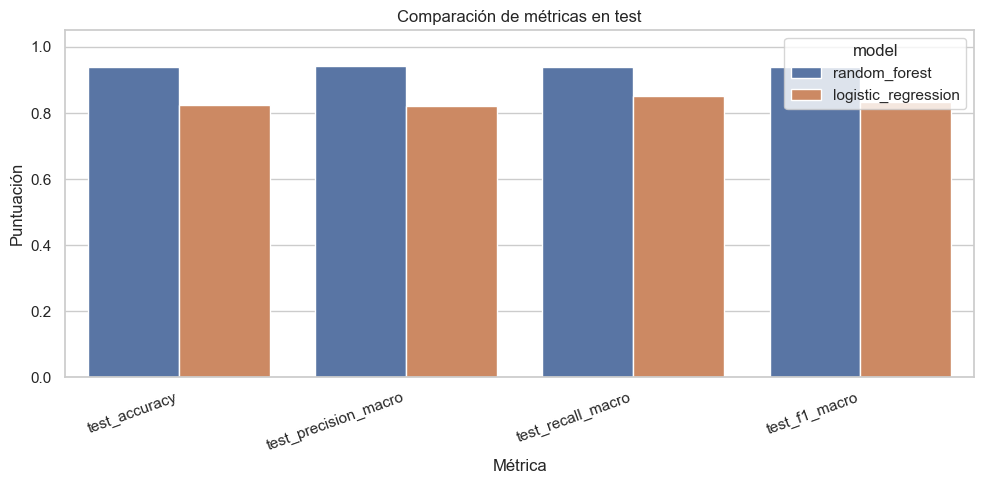

In [46]:
if SKIP_PLOTS:
    print('⏭️  SKIP_PLOTS=True, se omiten las gráficas.')
else:
    sns.set_theme(style='whitegrid')

    # ── 10.1 Comparación de métricas ────────────────────────────────────────
    print('📈 10.1 Comparación de métricas en test')
    plot_df = metrics_df.melt(
        id_vars='model',
        value_vars=['test_accuracy', 'test_precision_macro',
                    'test_recall_macro', 'test_f1_macro'],
        var_name='metric', value_name='score')
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x='metric', y='score', hue='model', ax=ax)
    ax.set_ylim(0, 1.05)
    ax.set_title('Comparación de métricas en test')
    ax.set_xlabel('Métrica'); ax.set_ylabel('Puntuación')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'metrics_comparison.png', dpi=160)
    plt.show()

📊 10.2 Matrices de confusión


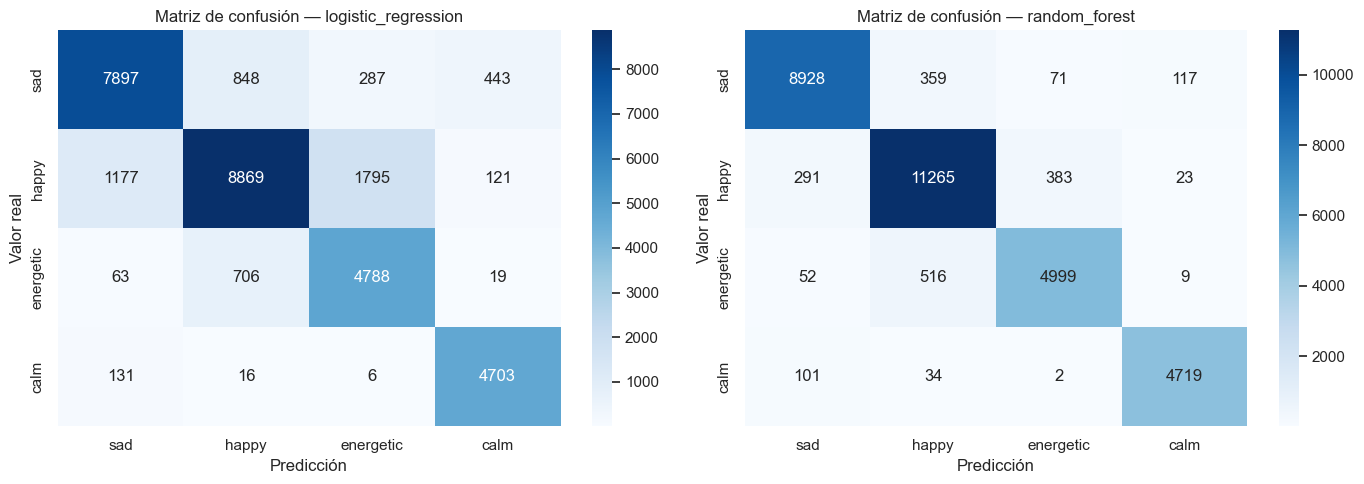

In [47]:
if not SKIP_PLOTS:
    # ── 10.2 Matrices de confusión ───────────────────────────────────────────
    print('📊 10.2 Matrices de confusión')
    labels = sorted(LABEL_NAMES)
    label_tick = [LABEL_NAMES[l] for l in labels]

    fig, axes = plt.subplots(1, len(fitted_models), figsize=(7 * len(fitted_models), 5))
    if len(fitted_models) == 1:
        axes = [axes]

    for ax, (model_name, search) in zip(axes, fitted_models.items()):
        y_pred_m = search.best_estimator_.predict(X_test)
        matrix   = confusion_matrix(y_test, y_pred_m, labels=labels)
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_tick, yticklabels=label_tick, ax=ax)
        ax.set_title(f'Matriz de confusión — {model_name}')
        ax.set_xlabel('Predicción'); ax.set_ylabel('Valor real')
        plt.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}.png', dpi=160)

    plt.tight_layout()
    plt.show()

🔮 10.3 Predicciones vs. valores reales (primeras 120 muestras)


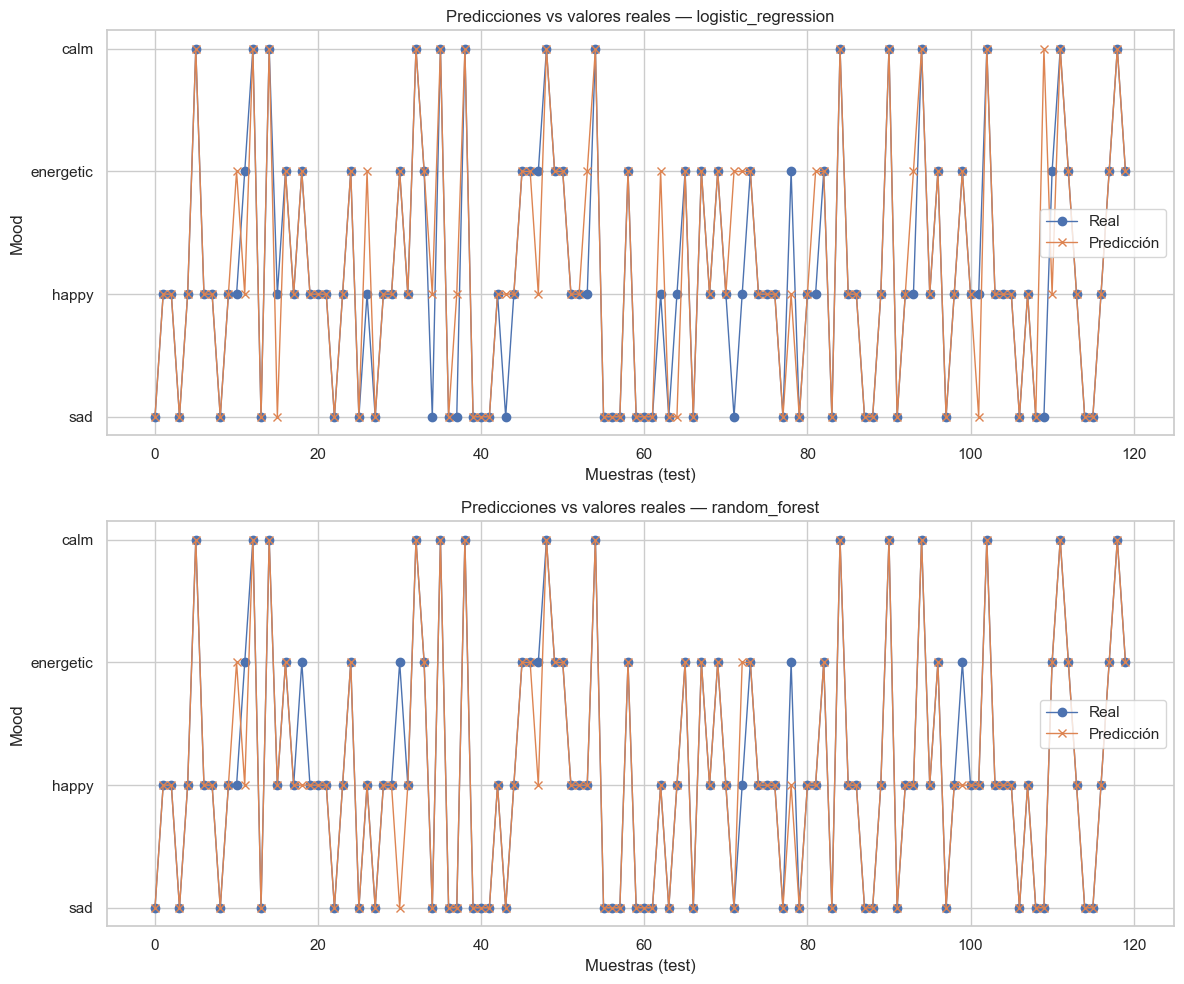

In [48]:
if not SKIP_PLOTS:
    # ── 10.3 Predicciones vs. valores reales (muestra) ───────────────────────
    print('🔮 10.3 Predicciones vs. valores reales (primeras 120 muestras)')

    fig, axes = plt.subplots(len(fitted_models), 1,
                             figsize=(12, 5 * len(fitted_models)))
    if len(fitted_models) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, fitted_models):
        sample = predictions_df[predictions_df['model'] == model_name].head(120)
        ax.plot(sample['sample_index'], sample['real_label'],
                marker='o', linewidth=1, label='Real')
        ax.plot(sample['sample_index'], sample['predicted_label'],
                marker='x', linewidth=1, label='Predicción')
        ax.set_yticks(list(LABEL_NAMES), [LABEL_NAMES[l] for l in LABEL_NAMES])
        ax.set_title(f'Predicciones vs valores reales — {model_name}')
        ax.set_xlabel('Muestras (test)'); ax.set_ylabel('Mood')
        ax.legend()
        plt.savefig(PLOTS_DIR / f'predictions_vs_real_{model_name}.png', dpi=160)

    plt.tight_layout()
    plt.show()

📉 10.4 Curva de aprendizaje — random_forest
[learning_curve] Training set sizes: [16996 33993 50989 67986 84983]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  1.4min finished


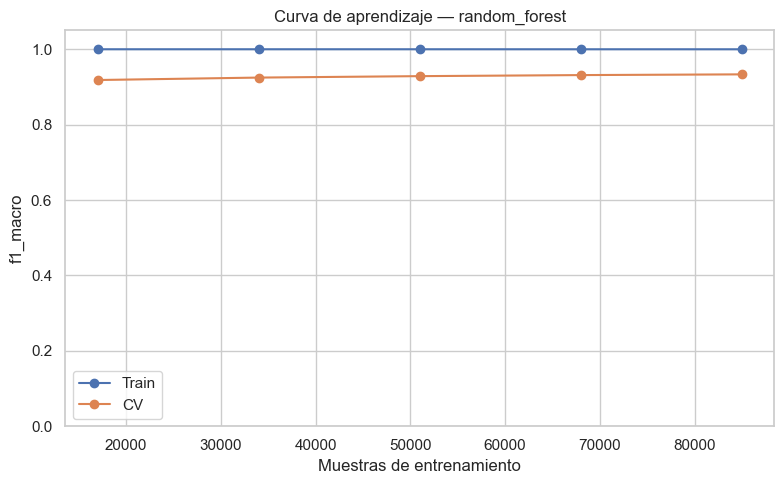

In [49]:
if not SKIP_PLOTS:
    # ── 10.4 Curva de aprendizaje (mejor modelo) ─────────────────────────────
    print(f'📉 10.4 Curva de aprendizaje — {best_model_name}')

    best_estimator = fitted_models[best_model_name].best_estimator_
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=best_estimator,
        X=X_train, y=y_train,
        cv=cv, scoring='f1_macro',
        n_jobs=-1,
        train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
        verbose=1,
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train')
    ax.fill_between(train_sizes,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
    ax.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='CV')
    ax.fill_between(train_sizes,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Curva de aprendizaje — {best_model_name}')
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('f1_macro')
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'learning_curve_{best_model_name}.png', dpi=160)
    plt.show()

🎯 10.5 Importancia de variables — random_forest


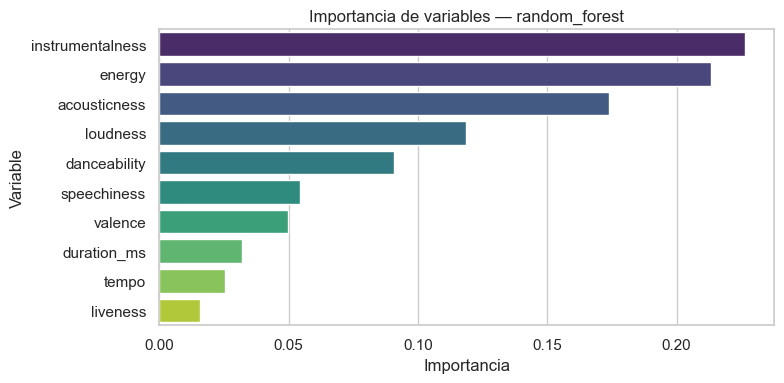

Top 5 features:


,feature,importance
0,instrumentalness,0.226323
1,energy,0.213420
2,acousticness,0.173890
3,loudness,0.118509
4,danceability,0.090725


In [50]:
if not SKIP_PLOTS:
    # ── 10.5 Importancia de features (mejor modelo) ──────────────────────────
    print(f'🎯 10.5 Importancia de variables — {best_model_name}')

    estimator_step = fitted_models[best_model_name].best_estimator_.named_steps['model']
    if hasattr(estimator_step, 'feature_importances_'):
        importance = estimator_step.feature_importances_
    elif hasattr(estimator_step, 'coef_'):
        importance = abs(estimator_step.coef_).mean(axis=0)
    else:
        importance = None
        print('   ℹ️  Este estimador no expone importancias de variables.')

    if importance is not None:
        imp_df = (pd.DataFrame({'feature': feature_cols, 'importance': importance})
                  .sort_values('importance', ascending=False))
        imp_df.to_csv(OUTPUT_DATA_DIR / f'feature_importance_{best_model_name}.csv', index=False)

        fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.4)))
        sns.barplot(data=imp_df, x='importance', y='feature', ax=ax, palette='viridis')
        ax.set_title(f'Importancia de variables — {best_model_name}')
        ax.set_xlabel('Importancia'); ax.set_ylabel('Variable')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f'feature_importance_{best_model_name}.png', dpi=160)
        plt.show()

        print('Top 5 features:')
        display(imp_df.head(5).reset_index(drop=True))

🎲 10.6 Distribución de confianza de predicción


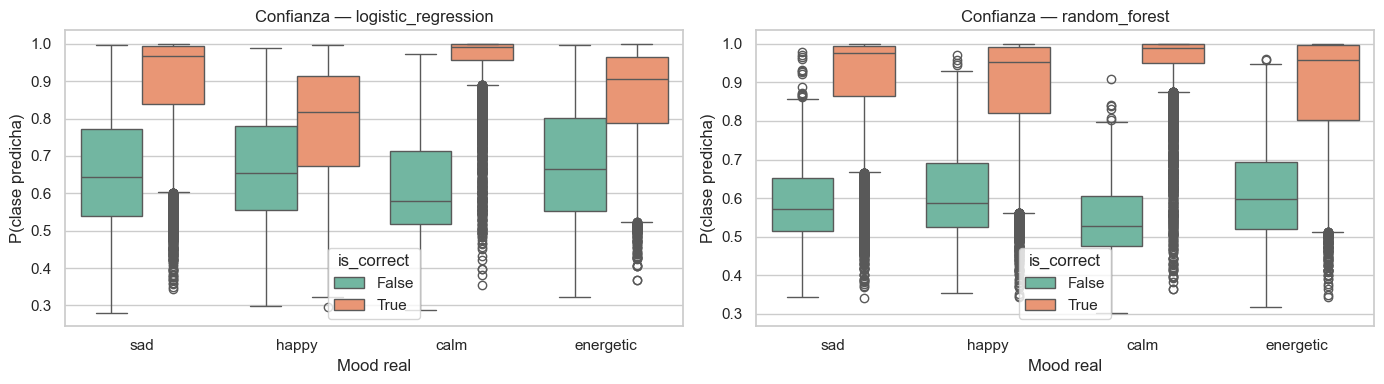

In [51]:
if not SKIP_PLOTS:
    # ── 10.6 Distribución de confianza por mood ──────────────────────────────
    has_conf = 'prediction_confidence' in predictions_df.columns
    if has_conf:
        print('🎲 10.6 Distribución de confianza de predicción')
        fig, axes = plt.subplots(1, len(fitted_models),
                                  figsize=(7 * len(fitted_models), 4))
        if len(fitted_models) == 1:
            axes = [axes]
        for ax, model_name in zip(axes, fitted_models):
            df_m = predictions_df[predictions_df['model'] == model_name]
            sns.boxplot(data=df_m, x='real_mood', y='prediction_confidence',
                        hue='is_correct', ax=ax, palette='Set2')
            ax.set_title(f'Confianza — {model_name}')
            ax.set_xlabel('Mood real'); ax.set_ylabel('P(clase predicha)')
        plt.tight_layout()
        plt.show()
    else:
        print('ℹ️  No hay probabilidades de predicción disponibles (modelo sin predict_proba).')

## 11. (Opcional) Subida a S3

In [52]:
import boto3

def upload_artifacts(settings, models_dir, metrics_dir):
    client = boto3.client(
        "s3",
        region_name=settings.aws_region,
        endpoint_url=settings.s3_endpoint_url,
    )
    for base_dir in [models_dir, metrics_dir]:
        for path in base_dir.rglob("*"):
            if not path.is_file():
                continue
            rel = path.relative_to(base_dir).as_posix()
            folder = "models" if base_dir == models_dir else "metrics"
            key = f"models/mood_classifier/{folder}/{rel}"
            client.upload_file(str(path), settings.bucket_name, key)
            print(f"Uploaded s3://{settings.bucket_name}/{key}")


try:
    settings  # type: ignore[name-defined]
except NameError:
    try:
        from src.config import load_settings
        settings = load_settings()
    except Exception as exc:
        settings = None
        print(f"Settings not available: {exc}")

if not UPLOAD_TO_S3:
    print("UPLOAD_TO_S3 is False - skipping upload")
elif settings is None or not getattr(settings, "bucket_name", None):
    print("Settings incomplete - check aws_credentials.env")
else:
    upload_artifacts(settings, OUTPUT_DIR, OUTPUT_DATA_DIR)

Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/activity_recommender_metadata.json
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/activity_recommender_mlp.joblib
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/activity_text_interpreter.joblib
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/activity_text_interpreter_metadata.json
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/mood_best_model.joblib
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/mood_logistic_regression.joblib
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/mood_random_forest.joblib
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_classifier/models/mood_training_summary.json
Uploaded s3://music-recommender-data-lake-246681677043/models/mood_class

## 12. Resumen final

In [53]:
print('=' * 60)
print('📋 RESUMEN FINAL')
print('=' * 60)
print(f'  Fuente de datos  : {source_used}')
print(f'  Split strategy   : {SPLIT_STRATEGY}')
print(f'  Train rows       : {len(train_df)}')
print(f'  Test rows        : {len(test_df)}')
print(f'  Features usadas  : {len(feature_cols)}')
print(f'  CV folds         : {CV_SPLITS}')
print()
print('  Resultados por modelo:')
for r in sorted(results, key=lambda x: x['test_f1_macro'], reverse=True):
    marker = '🏆' if r['model'] == best_model_name else '  '
    print(f"  {marker} {r['model']:<25}  "
          f"CV f1_macro={r['best_cv_f1_macro']:.4f}  "
          f"test f1_macro={r['test_f1_macro']:.4f}  "
          f"accuracy={r['test_accuracy']:.4f}  "
          f"({r['elapsed_seconds']}s)")
print()
print(f'  🏆 Mejor modelo: {best_model_name}')
print(f'  📁 Modelos      : {OUTPUT_DIR}')
print(f'  📁 Métricas     : {OUTPUT_DATA_DIR}')
print(f'  📁 Gráficas     : {PLOTS_DIR}')

📋 RESUMEN FINAL
  Fuente de datos  : s3://music-recommender-data-lake-246681677043/gold/mood_prepared
  Split strategy   : deduplicated
  Train rows       : 127475
  Test rows        : 31869
  Features usadas  : 10
  CV folds         : 3

  Resultados por modelo:
  🏆 random_forest              CV f1_macro=0.9333  test f1_macro=0.9395  accuracy=0.9386  (482.5s)
     logistic_regression        CV f1_macro=0.8328  test f1_macro=0.8327  accuracy=0.8239  (5.8s)

  🏆 Mejor modelo: random_forest
  📁 Modelos      : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models
  📁 Métricas     : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\model_outputs\mood_classifier
  📁 Gráficas     : C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\model_outputs\mood_classifier\plots
